In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [ ]:
# only get data analyst job in Indonesia 
df_DA_INA = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

# drop nan value 
df_DA_INA = df_DA_INA.dropna(subset=['salary_year_avg'])

Text(0, 0.5, 'Number of Jobs')

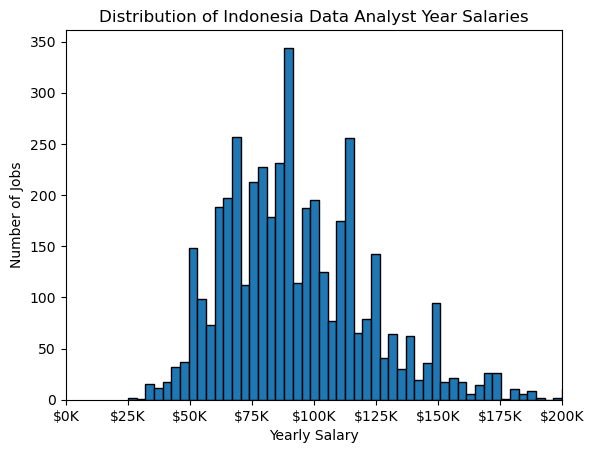

In [ ]:
df_DA_INA['salary_year_avg'].plot(kind='hist', bins=100, edgecolor='black')
plt.xlim(0,200000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ : f'Rp.{int(x/100)}K'))

plt.title('Distribution of Indonesia Data Analyst Year Salaries')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')